In [36]:
#Libs
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import zscore
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler



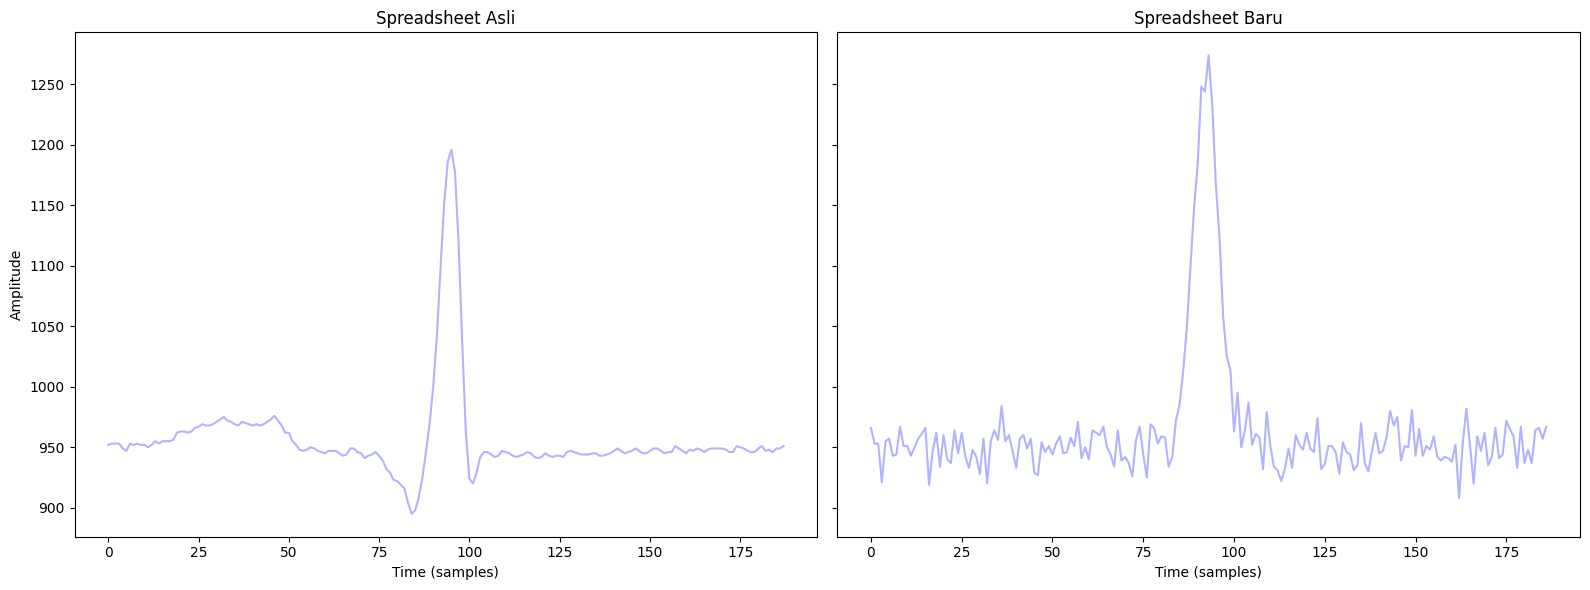

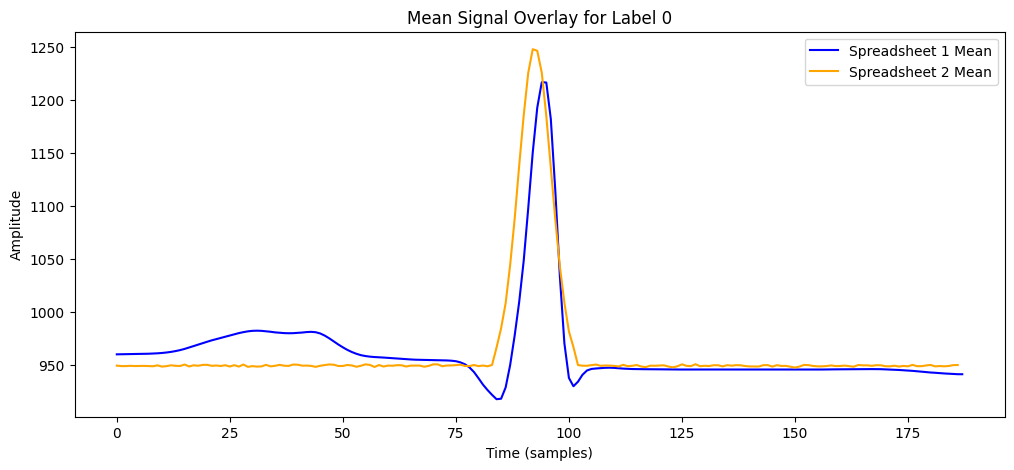

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

file1 = '/kaggle/input/ecg-dataset/ecg.csv'
file2 = '/kaggle/input/ecg2-dataset/ecg3.csv'

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

label_col = df1.columns[-1]

df1_label0 = df1[df1[label_col] == 0]
df2_label0 = df2[df2[label_col] == 0]

def plot_overlay(df, title):
    plt.figure(figsize=(12, 6))
    for idx, row in df.iterrows():
        signal = row[:-1].values.astype(float)
        plt.plot(signal, color='blue', alpha=0.3)
    plt.title(title)
    plt.xlabel('Time (samples)')
    plt.ylabel('Amplitude')
    plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Spreadsheet 1
j=0
for idx, row in df1_label0.iterrows():
    if j==0:
        signal = row[:-1].values.astype(float)
        axes[0].plot(signal, color='blue', alpha=0.3)
    else:
        pass
    j=1
axes[0].set_title('Spreadsheet Asli')
axes[0].set_xlabel('Time (samples)')
axes[0].set_ylabel('Amplitude')

# Spreadsheet 2
i = 0
for idx, row in df2_label0.iterrows():
    if i ==0:
        signal = row[:-1].values.astype(float)
        axes[1].plot(signal, color='blue', alpha=0.3)
    else:
        pass
    i=1
axes[1].set_title('Spreadsheet Baru')
axes[1].set_xlabel('Time (samples)')

plt.tight_layout()
plt.show()

# mean signal difference
mean_signal1 = df1_label0.iloc[:, :-1].mean(axis=0).values.astype(float)
mean_signal2 = df2_label0.iloc[:, :-1].mean(axis=0).values.astype(float)

plt.figure(figsize=(12, 5))
plt.plot(mean_signal1, color='blue', label='Spreadsheet 1 Mean')
plt.plot(mean_signal2, color='orange', label='Spreadsheet 2 Mean')
plt.title('Mean Signal Overlay for Label 0')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()


# Data Setup

In [38]:
df1 = pd.read_csv('/kaggle/input/ecg-dataset/ecg.csv',header=None)
df2 = pd.read_csv('/kaggle/input/ecg2-dataset/ecg3.csv',header=None)
print(df2.columns[:10])

#temp fix copy first column
df2 = df2.rename(columns={0: 'orig_0'})
df2.insert(0, 0, df2['orig_0'])
df2.columns = range(df2.shape[1])
print("after:")
print(df2.columns[:10])

print(df1.shape)
print(df2.shape)


count1=len(df1)
count2=len(df2)

print("total of ori & extra data:")
print("ori:",count1," and extra:", count2)

count1_1 = (df1.iloc[:, -1] == 0).sum()
count1_2 = (df1.iloc[:, -1] == 1).sum()
count2_1 = (df2.iloc[:, -1] == 0).sum()
count2_2 = (df2.iloc[:, -1] == 1).sum()

print("types of ori df:")
print("normal:",count1_1,". abnormal:", count1_2)

print("types of extra df:")
print("normal:",count2_1,". abnormal:", count2_2)

df = pd.concat([df1, df2], ignore_index=True)

count3_1 = (df.iloc[:, -1] == 0).sum()
count3_2 = (df.iloc[:, -1] == 1).sum()

print("total combined length")
print(len(df))

print("total types:")
print("normal:",count3_1,". abnormal:", count3_2)
df.head(10)

Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype='int64')
after:
RangeIndex(start=0, stop=10, step=1)
(4025, 189)
(1000, 189)
total of ori & extra data:
ori: 4025  and extra: 1000
types of ori df:
normal: 2236 . abnormal: 1789
types of extra df:
normal: 500 . abnormal: 500
total combined length
5025
total types:
normal: 2736 . abnormal: 2289


,0,1,2,3,4,5,6,7,8,9,...,179,180,181,182,183,184,185,186,187,188
0,955,954,954,956,958,955,955,953,954,956,...,941,940,940,939,941,941,942,937,938,0
1,952,953,953,953,949,947,953,952,953,952,...,946,949,951,947,948,946,949,949,951,0
2,955,948,952,952,955,955,954,953,955,958,...,939,934,935,934,937,935,930,933,932,0
3,957,958,958,958,956,956,956,959,959,959,...,939,939,942,942,940,938,935,936,937,0
4,958,958,960,960,958,958,959,961,961,961,...,944,946,949,949,950,947,946,946,946,0
5,952,954,956,955,955,953,952,952,951,955,...,943,938,941,942,941,938,935,931,932,0
6,954,952,952,954,953,956,955,953,953,953,...,944,943,940,938,939,942,942,943,941,0
7,960,961,960,957,957,960,959,961,960,960,...,948,948,948,949,946,945,947,947,949,0
8,960,960,960,962,963,966,967,966,963,962,...,957,954,951,948,947,953,952,953,950,0
9,961,964,962,961,963,962,960,962,964,965,...,940,938,938,939,940,938,935,931,933,0


In [39]:
#Adding Label
adding_columns = [f'f{i}' for i in range(0, 188)] + ['label']
df.columns = adding_columns

In [40]:
df

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f179,f180,f181,f182,f183,f184,f185,f186,f187,label
0,955,954,954,956,958,955,955,953,954,956,...,941,940,940,939,941,941,942,937,938,0
1,952,953,953,953,949,947,953,952,953,952,...,946,949,951,947,948,946,949,949,951,0
2,955,948,952,952,955,955,954,953,955,958,...,939,934,935,934,937,935,930,933,932,0
3,957,958,958,958,956,956,956,959,959,959,...,939,939,942,942,940,938,935,936,937,0
4,958,958,960,960,958,958,959,961,961,961,...,944,946,949,949,950,947,946,946,946,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5020,977,977,956,954,932,961,941,953,950,953,...,910,973,933,957,946,943,938,959,943,1
5021,932,932,966,944,941,928,958,941,933,939,...,961,970,963,964,960,941,941,925,926,1
5022,952,952,946,944,948,936,957,945,954,946,...,944,932,938,942,954,946,930,931,934,0
5023,953,953,960,953,951,942,955,957,925,937,...,948,927,948,965,943,942,953,936,962,1


# Exploratory Data Analysis (EDA)

In [41]:
#EDA Data Analysis
df.describe()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f179,f180,f181,f182,f183,f184,f185,f186,f187,label
count,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,...,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000,5025.000000
mean,940.380299,943.126766,943.348856,942.763781,943.633433,944.701294,944.433831,943.738507,945.345871,945.781095,...,941.051343,941.299303,941.985672,942.658706,944.233234,942.591841,943.773532,944.740299,945.087363,0.455522
std,41.294900,40.178182,40.634467,40.987698,41.206112,39.453267,39.897625,43.399855,40.251115,38.932959,...,61.786028,63.425755,63.241259,64.287155,63.819717,66.924980,66.308579,66.680679,67.204041,0.498067
min,562.000000,596.000000,552.000000,603.000000,539.000000,596.000000,583.000000,481.000000,556.000000,543.000000,...,610.000000,551.000000,620.000000,566.000000,594.000000,464.000000,440.000000,581.000000,553.000000,0.000000
25%,926.000000,931.000000,932.000000,933.000000,933.000000,934.000000,933.000000,934.000000,935.000000,935.000000,...,925.000000,924.000000,924.000000,924.000000,924.000000,923.000000,923.000000,924.000000,923.000000,0.000000
50%,952.000000,953.000000,953.000000,954.000000,954.000000,954.000000,954.000000,954.000000,955.000000,955.000000,...,943.000000,942.000000,942.000000,942.000000,942.000000,942.000000,942.000000,942.000000,941.000000,0.000000
75%,963.000000,964.000000,965.000000,965.000000,965.000000,965.000000,965.000000,965.000000,966.000000,966.000000,...,955.000000,955.000000,955.000000,955.000000,954.000000,955.000000,954.000000,954.000000,954.000000,1.000000
max,1252.000000,1216.000000,1212.000000,1174.000000,1314.000000,1243.000000,1337.000000,1292.000000,1249.000000,1182.000000,...,1306.000000,1307.000000,1303.000000,1304.000000,1314.000000,1319.000000,1324.000000,1327.000000,1334.000000,1.000000


In [42]:
df.shape

(5025, 189)

In [43]:
#Data Distribution
print(df['label'].value_counts(normalize=True) * 100)

label
0    54.447761
1    45.552239
Name: proportion, dtype: float64


In [44]:
#Missing Value (zeroed value)
print(df.isnull().sum())

f0       0
f1       0
f2       0
f3       0
f4       0
        ..
f184     0
f185     0
f186     0
f187     0
label    0
Length: 189, dtype: int64


# Outlier Removal

In [45]:
#Outlier check
z_scores = zscore(df.drop('label', axis=1))

#Check outliers where Z_score is more than 3
outliers = (abs(z_scores) > 3)

#Count outliers per column
outlier_counts = outliers.sum(axis=0)
print(outlier_counts)

[ 79  87  89  86  84  89  91  92  91  89  93  81  88  93  88  90  85  78
  83  91  91  88  92  86  89  76  86  77  79  78  69  78  85  79  89  83
  85  93  80  86  91  87  87  69  70  84  77  78  83  72  92  93  87  97
  94  93  92  93  92  99  87  84  98  80  84  85  81  84  87  82  79  83
  94  97  95  65  40  48  57  81 126 144 162 166 169 164 153  46  14   9
   5   4   2   1   2   0   0   5   9   9  12  15  16  23  30  35  39  56
  64  86  83  84 131 140 157 174 184 189 198 201 219 216 217 216 219 230
 230 237 239 239 237 240 238 229 211 189 178 171 149 138 120  74  58  46
  43  44  47  45  57  63  49  63  64  64  81  81  90  86  89  93  91  94
  94  79  89  79  73  76  83  81  84  90  86  88  90  94  87 100 107 109
 117 109 117 120 122 128 137 138]


In [46]:
#Check total outlier, since number of outlieris less than 10%, just delete the outlier
num_outlier_rows = outliers.any(axis=1).sum()
num_outlier_rows

1321

In [47]:
#Z-score calculation except rom label column
z_scores = zscore(df.drop('label', axis=1))

#Outlier rows detection
mask = (abs(z_scores) <= 3).all(axis=1)

#save rows that doesn't contain outliers
df_clean = df[mask].reset_index(drop=True)

print(f"Initial Data: {df.shape[0]} rows")
print(f"Cleaned Outlier Data: {df_clean.shape[0]} rows")

Initial Data: 5025 rows
Cleaned Outlier Data: 3704 rows


In [48]:
#Data Distribution
print(df_clean['label'].value_counts(normalize=True) * 100)

label
0    73.866091
1    26.133909
Name: proportion, dtype: float64


In [49]:
# #Make sure after data cleaning, all the data are still balanced
# count_label_0 = df_clean[df_clean['label'] == 0].shape[0]
# count_label_1 = df_clean[df_clean['label'] == 1].shape[0]

# df_label_0_sampled = df_clean[df_clean['label'] == 0].sample(n=count_label_1, random_state=42)
# df_label_1 = df_clean[df_clean['label'] == 1]

# df_final = pd.concat([df_label_0_sampled, df_label_1]).sample(frac=1, random_state=42).reset_index(drop=True)
# print(df_final['label'].value_counts(normalize=True) * 100)
df_final = df

In [50]:
#save the cleaned dataset
df_final.to_csv('cleaned_ECG_data.csv', index=False)
df = df_final

# Check Abnormal Data Diversity With K-Means

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


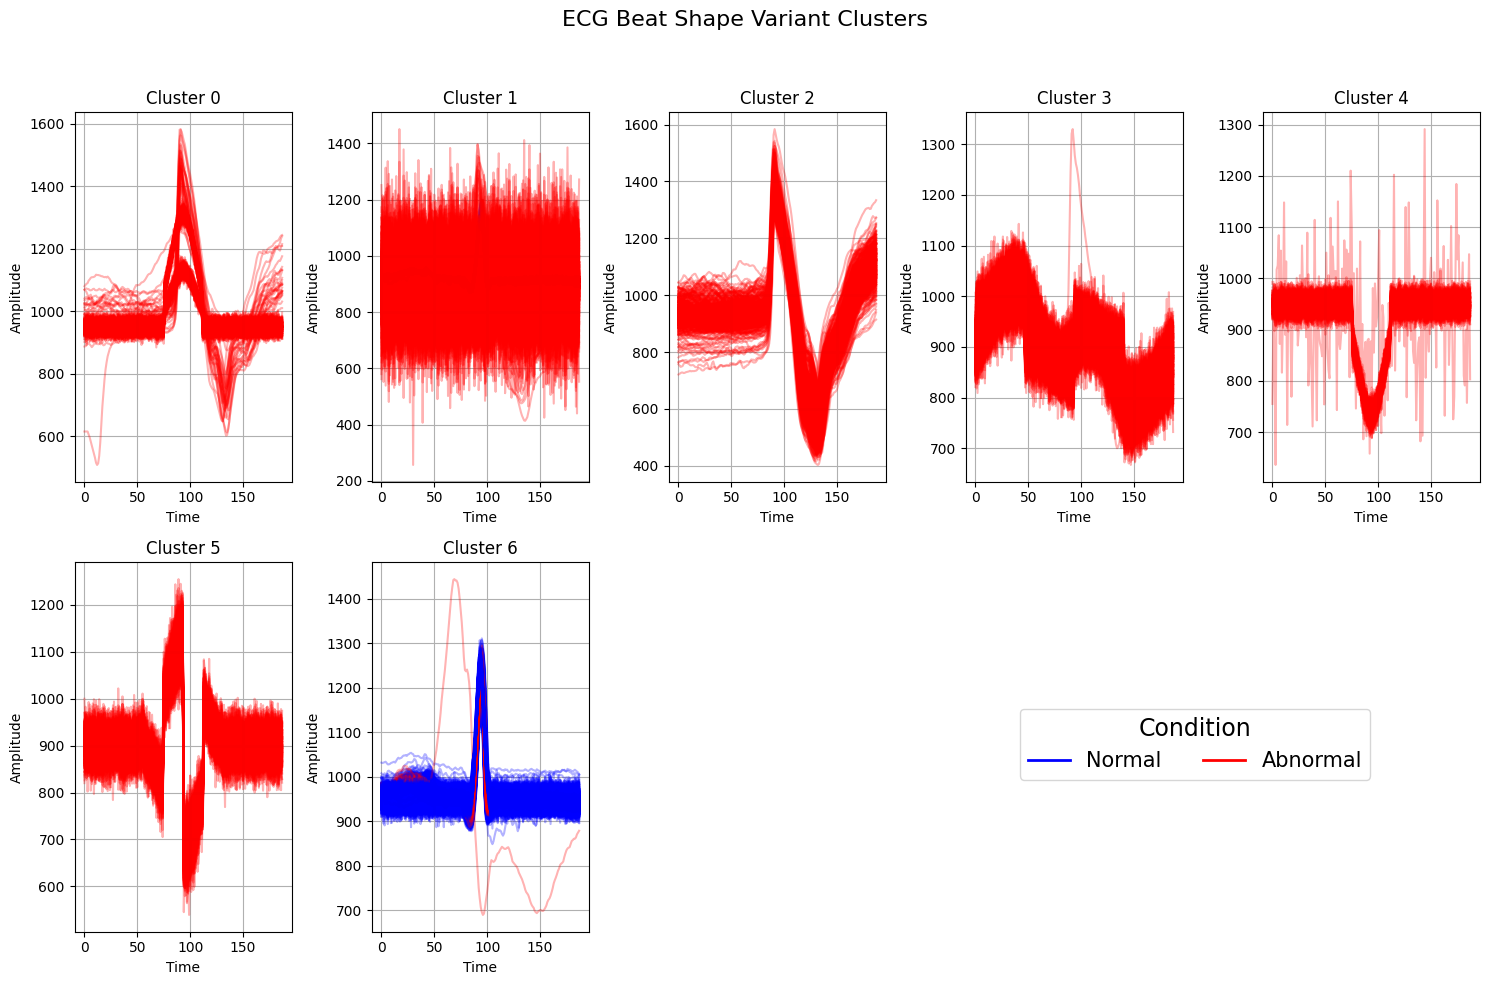

In [51]:
X1 = df.iloc[:, :-1].values
y1 = df.iloc[:, -1].values 

#normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X1)

n_clusters = 7

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label='Normal'),
    Line2D([0], [0], color='red', lw=2, label='Abnormal')
]

fig = plt.figure(figsize=(15, 10))
rows = (n_clusters + 4) // 5

for cluster_id in range(n_clusters):
    ax = fig.add_subplot(rows, 5, cluster_id + 1)
    cluster_indices = np.where(clusters == cluster_id)[0]
    
    for idx in cluster_indices:
        color = 'red' if y1[idx] == 1 else 'blue'
        ax.plot(X1[idx], color=color, alpha=0.3)

    ax.set_title(f'Cluster {cluster_id}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Amplitude')
    ax.grid(True)

fig.legend(
    handles=legend_elements,
    loc='lower center', 
    bbox_to_anchor=(0.8, 0.2),
    ncol=2,
    title='Condition',
    fontsize=15,   
    title_fontsize=17,
    frameon=True
)
y_labels = {0: 'normal', 1: 'abnormal'}
fig.suptitle('ECG Beat Shape Variant Clusters', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# PCA Dimension Reduction

In [52]:
#PCA dimension reduction
print(df.columns.tolist())
X = df.drop('label', axis=1)
y = df['label']

#Feature Normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Implement PCA to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34', 'f35', 'f36', 'f37', 'f38', 'f39', 'f40', 'f41', 'f42', 'f43', 'f44', 'f45', 'f46', 'f47', 'f48', 'f49', 'f50', 'f51', 'f52', 'f53', 'f54', 'f55', 'f56', 'f57', 'f58', 'f59', 'f60', 'f61', 'f62', 'f63', 'f64', 'f65', 'f66', 'f67', 'f68', 'f69', 'f70', 'f71', 'f72', 'f73', 'f74', 'f75', 'f76', 'f77', 'f78', 'f79', 'f80', 'f81', 'f82', 'f83', 'f84', 'f85', 'f86', 'f87', 'f88', 'f89', 'f90', 'f91', 'f92', 'f93', 'f94', 'f95', 'f96', 'f97', 'f98', 'f99', 'f100', 'f101', 'f102', 'f103', 'f104', 'f105', 'f106', 'f107', 'f108', 'f109', 'f110', 'f111', 'f112', 'f113', 'f114', 'f115', 'f116', 'f117', 'f118', 'f119', 'f120', 'f121', 'f122', 'f123', 'f124', 'f125', 'f126', 'f127', 'f128', 'f129', 'f130', 'f131', 'f132', 'f133', 'f134', 'f135', 'f136', 'f137', 'f138

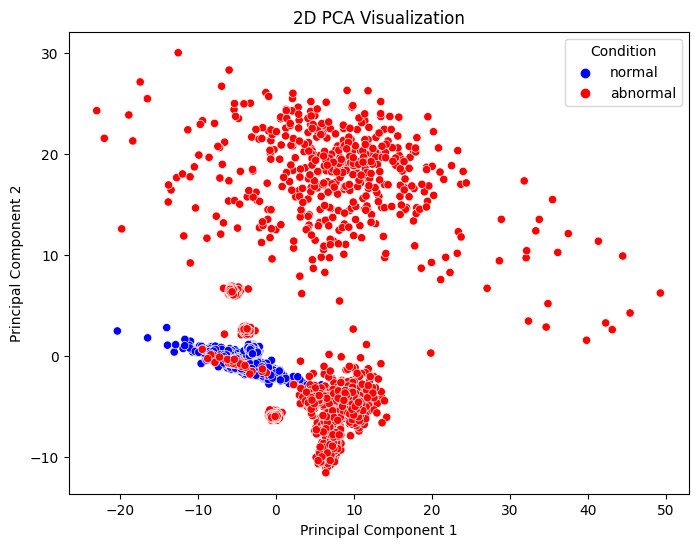

In [53]:
#PCA result
plt.figure(figsize=(8,6))
custom_palette = {0: 'blue', 1: 'red'}
sns.scatterplot(x=X_pca[:, 0],y=X_pca[:, 1],hue=[y_labels[val] for val in y],
                palette={'normal': 'blue', 'abnormal': 'red'})
plt.legend(title='Condition')
plt.title("2D PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Data Preparation

In [54]:
#Dataset Preparation
X = df.drop('label', axis=1).values
y = df['label'].values

In [55]:
#1 dimension only since ECG data is 1 dimensional (Voltage against time)
X = X.reshape((X.shape[0], X.shape[1], 1))

In [56]:
#Encode the labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

In [57]:
#Spiting DS
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

# Model Definition

In [58]:
#1Conv Train
model = Sequential([
    Conv1D(64, kernel_size=5, activation='relu', input_shape=(X.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    Conv1D(128, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(y_categorical.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)                    │ (None, 184, 64)             │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 92, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 92, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 88, 128)             │          41,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ (None, 44, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 44, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 5632)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         721,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 762,754 (2.91 MB)

 Trainable params: 762,754 (2.91 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
#save model visual to output
# from tensorflow.keras.utils import plot_model
# plot_model(model, to_file='/kaggle/working/model.png', show_shapes=True, show_layer_names=True)

# Model Training

In [ ]:
#checkpoint to get best model only
checkpoint = ModelCheckpoint(
    '/kaggle/working/ecg_best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)
#train
model.fit(
    X_train, y_train,
    epochs=500,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint]
)

Epoch 1/500
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5138 - loss: 56.9720
Epoch 1: val_loss improved from inf to 0.69396, saving model to /kaggle/working/ecg_best_model.h5
126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.5138 - loss: 56.6542 - val_accuracy: 0.4537 - val_loss: 0.6940
Epoch 2/500
120/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5374 - loss: 0.6940
Epoch 2: val_loss did not improve from 0.69396
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5373 - loss: 0.6938 - val_accuracy: 0.5463 - val_loss: 0.7019
Epoch 3/500
121/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5266 - loss: 0.7046
Epoch 3: val_loss improved from 0.69396 to 0.68687, saving model to /kaggle/working/ecg_best_model.h5
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5277 - loss: 0.7039 - val_accuracy: 0.4537 - val_loss: 0.6869
Epoch 4/500
124/126 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5403 - loss: 0.6866
Epoch 4: val_loss improved from 0.68687 to 0.67172

# Evaluation

In [ ]:
#Accuracy
loss, acc = model.evaluate(X_test, y_test)
print(f"Accuracy: {acc:.4f}")

In [ ]:
#Confusion Matrix
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()


# Prediction

In [ ]:
#Prediction
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

In [ ]:
#Prediction confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_true_classes, y_pred_classes)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot()

# Final Report

In [ ]:
#Clarification Report
from sklearn.metrics import classification_report
target_names = [str(label) for label in le.classes_]
print(classification_report(y_true_classes, y_pred_classes, target_names=target_names))


In [ ]:
#ROC-AUC
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test, y_pred, multi_class='ovr')
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Prediction

In [ ]:
#Data for Testing
data = [
    952, 954, 956, 955, 955, 953, 952, 952, 951, 955, 953, 954, 952, 953, 952, 955,
    957, 958, 958, 962, 963, 964, 963, 965, 963, 967, 969, 971, 973, 973, 972, 971,
    973, 973, 972, 968, 966, 968, 970, 973, 969, 966, 960, 964, 965, 970, 971, 970,
    967, 964, 962, 961, 960, 954, 950, 951, 951, 951, 950, 950, 950, 948, 952, 949,
    949, 944, 940, 943, 944, 947, 948, 944, 941, 943, 945, 945, 945, 942, 938, 936,
    933, 926, 927, 920, 910, 909, 919, 940, 963, 986, 1020, 1068, 1121, 1167, 1193,
    1201, 1182, 1136, 1069, 1010, 967, 939, 924, 914, 917, 924, 931, 934, 934, 937,
    940, 942, 942, 941, 940, 939, 940, 938, 938, 936, 934, 934, 938, 938, 938, 935,
    935, 936, 939, 938, 938, 939, 935, 935, 938, 937, 937, 935, 935, 937, 938, 939,
    938, 938, 936, 940, 938, 939, 938, 936, 936, 938, 938, 941, 939, 938, 933, 935,
    935, 938, 938, 936, 936, 937, 938, 941, 941, 939, 939, 940, 943, 943, 941, 941,
    939, 938, 943, 943, 943, 943, 938, 941, 942, 941, 938, 935, 931, 932
]
data_category = 0


In [ ]:
#Predict Function
def predict(signal):
    signal = np.array(data)
    # signal = (signal - np.mean(signal)) / np.std(signal) #Input normalization
    signal = signal.reshape(1, -1, 1)
    y_pred = model.predict(signal)
    predicted_class = np.argmax(y_pred)
    predicted_label = le.inverse_transform([predicted_class])[0]
    print(f"Prediction Result: {predicted_label}, expected to be: {data_category}")
    

In [ ]:
predict(data)

# Save Model

In [ ]:
model.save('/kaggle/working/ecg_last_model.h5')